In [1]:
!pip install numpy matplotlib rasterio scikit-learn

# Classificação de áreas queimadas — RBF-SVM sobre dNBR

Pipeline de **classificação supervisionada pixel-a-pixel** de áreas queimadas
em imagens Landsat 8/9, usando **SVM com kernel RBF** sobre o índice
**dNBR = NBR_pré − NBR_pós**.

## Visão geral

| Etapa | Cena | O quê |
|---|---|---|
| **Treino** | `220_075/` | Carrega NBR pré/pós, calcula dNBR, treina SVM com `GridSearchCV`. |
| **Holdout interno** | `220_075/` | Mede o desempenho num split estratificado da própria cena de treino — aproxima do erro de generalização *na mesma cena*. |
| **Teste cego** | `221_074/` | Aplica o modelo numa cena **nunca vista**. Mede a generalização real entre cenas. |
| **Saída** | — | Escreve duas máscaras 0/1 georreferenciadas em `saida_modelo/`. |

## Decisões de design (e por quê)

- **Feature**: apenas `dNBR`. Atende ao requisito "usar só os arquivos NBR de
  `img_pre`/`img_pos`". RBF-SVM em 1D ainda é útil porque aprende **o threshold ótimo
  a partir dos dados** (em vez do fixo 0,27 do Key & Benson 2006), e pode capturar
  faixas não-monotônicas (ex.: dNBR muito alto pode ser nuvem/sombra, não queimada).
- **Reprojeção para o grid da máscara** antes de subtrair NBR_pré − NBR_pós:
  os recortes vêm com bounds ligeiramente diferentes, então `rasterio.warp.reproject`
  garante alinhamento exato. Isso é o que faz a Seção 3 antes de qualquer subtração.
- **Sub-amostragem estratificada do treino** (~20 mil pixels): RBF-SVM escala
  $O(n^2)$–$O(n^3)$ no número de amostras. Cenas com dezenas de milhões de pixels
  inviabilizam o ajuste direto.
- **`Pipeline(StandardScaler → SVC)` + `GridSearchCV`**: garante que a normalização
  é ajustada **por fold** (sem data leakage) e o tuning de `C, γ` é feito na CV.
- **`class_weight="balanced"`**: a classe queimada é minoritária (~5–8%); o peso
  inverso à frequência evita um modelo que prediz "tudo não queimada".
- **Métricas**: `Accuracy`, `Precision`, `Recall`, `F1`, `Cohen's κ`, `ROC-AUC`,
  matriz de confusão. **κ é a referência em sensoriamento remoto** (Congalton 1991)
  porque corrige pelo acaso em cenários desbalanceados.
- **Baseline obrigatório** antes do modelo: `dNBR > 0,27` (Key & Benson 2006).
  O SVM precisa **bater** esse número — caso contrário não vale a complexidade.
- **Reprodutibilidade**: `random_state=42` em todos os pontos estocásticos.

## 1. Imports e configuração global

Imports, logger estruturado (`logging`, não `print` em código de pipeline) e
seed fixa para reprodutibilidade.

In [2]:
from __future__ import annotations

import logging
import warnings
from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import rasterio
from matplotlib.colors import ListedColormap
from rasterio.warp import Resampling, reproject
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    cohen_kappa_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

warnings.filterwarnings("ignore", category=RuntimeWarning)
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s [%(levelname)s] %(message)s",
    datefmt="%H:%M:%S",
)
logger = logging.getLogger("burnedarea")

SEED = 42
np.random.seed(SEED)

## 2. ENTRADAS — paths das cenas e diretório de saída

**Tudo o que o usuário precisa editar está nesta célula.** Cada cena é
descrita por três arquivos:

| Campo | O quê |
|---|---|
| `nbr_pre` | NBR da imagem pré-fogo. |
| `nbr_pos` | NBR da imagem pós-fogo. |
| `mask`    | Máscara binária (`0` = não queimada, `1` = queimada). Ground truth. |

A cena de **treino** é usada para ajustar o SVM. A cena de **teste cego**
é usada apenas no final, para medir generalização entre cenas.

A pasta `OUTPUT_DIR` recebe os dois GeoTIFFs com a predição final.

In [3]:
@dataclass(frozen=True)
class Scene:
    name: str
    nbr_pre: Path
    nbr_pos: Path
    mask: Path


# Cena de TREINO ------------------------------------------------------------
TRAIN_SCENE = Scene(
    name="220_075",
    nbr_pre=Path("220_075/img_pre/LC08_L2SP_220075_20240821_NBR.tif"),
    nbr_pos=Path("220_075/img_pos/LC09_L2SP_220075_20240829_NBR.tif"),
    mask=Path("220_075/mascara_0_1/mascara_1_0_areaqueimada_lim_0-65_nbr.tif"),
)

# Cena de TESTE CEGO --------------------------------------------------------
TEST_SCENE = Scene(
    name="221_074",
    nbr_pre=Path("221_074/img_pre/LC09_L2SP_221074_20240820_NBR.tif"),
    nbr_pos=Path("221_074/img_pos/LC08_L2SP_221074_20240828_NBR.tif"),
    mask=Path("221_074/mascara_0_1/mascara_1_0_areaqueimada_lim_0-65_nbr.tif"),
)

# Saída do modelo (GeoTIFFs com a máscara binária predita) ------------------
OUTPUT_DIR = Path("/home/queimadas/Desktop/dados_trabalho_final/saida_modelo")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

logger.info("Treino : %s", TRAIN_SCENE.name)
logger.info("Teste  : %s", TEST_SCENE.name)
logger.info("Saída  : %s", OUTPUT_DIR)

17:03:14 [INFO] Treino : 220_075
17:03:14 [INFO] Teste  : 221_074
17:03:14 [INFO] Saída  : /home/queimadas/Desktop/dados_trabalho_final/saida_modelo


## 3. Funções de I/O e cálculo de dNBR (com alinhamento)

Os recortes Landsat de pré e pós-fogo geralmente têm bounds ligeiramente
diferentes (deslocamento de poucos pixels) e até CRS distintos entre cenas.
Subtrair `NBR_pré − NBR_pós` direto explode com `ValueError` de shape.

A função `load_aligned_to(...)` resolve isso com `rasterio.warp.reproject`,
**reamostrando** o raster fonte para o grid (CRS + transform + shape) de uma
referência. Usamos a **máscara como referência** porque é o ground truth e
todas as métricas precisam estar nesse mesmo grid.

A função `compute_dnbr(...)` empacota o passo a passo: lê a máscara, alinha
NBR pré e pós ao grid dela, e retorna `(dnbr, mask_int8)`.

In [4]:
def load_band(path: Path, band: int = 1) -> np.ndarray:
    """Lê uma banda como float32, propagando nodata como NaN."""
    with rasterio.open(path) as src:
        arr = src.read(band).astype(np.float32)
        if src.nodata is not None:
            arr[arr == src.nodata] = np.nan
    return arr


def load_aligned_to(src_path: Path, ref_path: Path) -> np.ndarray:
    """Lê `src_path` reprojetado para o grid (CRS + transform + shape) de `ref_path`.

    Reamostragem bilinear (apropriada para índices contínuos).
    Pixels sem cobertura na fonte ficam como NaN.
    """
    with rasterio.open(ref_path) as ref:
        dst_shape = ref.shape
        dst_transform = ref.transform
        dst_crs = ref.crs

    dst = np.full(dst_shape, np.nan, dtype=np.float32)

    with rasterio.open(src_path) as src:
        reproject(
            source=rasterio.band(src, 1),
            destination=dst,
            src_transform=src.transform,
            src_crs=src.crs,
            dst_transform=dst_transform,
            dst_crs=dst_crs,
            resampling=Resampling.bilinear,
            src_nodata=src.nodata,
            dst_nodata=np.nan,
        )
    return dst


def load_mask(path: Path) -> np.ndarray:
    """Carrega máscara como int8: 0 = não queimada, 1 = queimada, -1 = inválido."""
    raw = load_band(path)
    out = np.full(raw.shape, -1, dtype=np.int8)
    out[raw == 0] = 0
    out[raw == 1] = 1
    return out


def compute_dnbr(scene: Scene) -> tuple[np.ndarray, np.ndarray]:
    """Retorna `(dnbr, mask)` para uma cena, ambos no grid da máscara.

    dnbr = NBR_pre - NBR_pos. Pixels com NaN em qualquer dos dois ficam NaN.
    """
    logger.info("[%s] carregando máscara", scene.name)
    mask = load_mask(scene.mask)

    logger.info("[%s] alinhando NBR_pre ao grid da máscara", scene.name)
    nbr_pre = load_aligned_to(scene.nbr_pre, scene.mask)

    logger.info("[%s] alinhando NBR_pos ao grid da máscara", scene.name)
    nbr_pos = load_aligned_to(scene.nbr_pos, scene.mask)

    dnbr = nbr_pre - nbr_pos
    logger.info("[%s] dNBR shape=%s, máscara shape=%s", scene.name, dnbr.shape, mask.shape)
    return dnbr, mask


def features_and_targets(
    dnbr: np.ndarray, mask: np.ndarray
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Empacota (X, y, valid_pixels) com 1 feature (dNBR) e máscara binária."""
    X = dnbr.reshape(-1, 1)
    y = mask.ravel()
    valid = (y >= 0) & np.isfinite(X[:, 0])
    return X[valid], y[valid].astype(np.int8), valid

## 4. Carregar a cena de TREINO (220_075)

Aqui realmente lemos os rasters da cena de treino e calculamos `dNBR`.
A partir daqui, `train_dnbr` e `train_mask` são arrays 2D no grid da máscara.

In [5]:
train_dnbr, train_mask = compute_dnbr(TRAIN_SCENE)
train_H, train_W = train_mask.shape

n_burn = int((train_mask == 1).sum())
n_unburn = int((train_mask == 0).sum())
n_invalid = int((train_mask == -1).sum())
logger.info(
    "Treino %s: %d x %d, queimada=%d (%.2f%%), não queimada=%d (%.2f%%), inválido=%d",
    TRAIN_SCENE.name, train_H, train_W,
    n_burn, 100 * n_burn / train_mask.size,
    n_unburn, 100 * n_unburn / train_mask.size,
    n_invalid,
)

17:03:14 [INFO] [220_075] carregando máscara
17:03:14 [INFO] [220_075] alinhando NBR_pre ao grid da máscara
17:03:16 [INFO] [220_075] alinhando NBR_pos ao grid da máscara
17:03:17 [INFO] [220_075] dNBR shape=(7691, 7581), máscara shape=(7691, 7581)
17:03:17 [INFO] Treino 220_075: 7691 x 7581, queimada=3199001 (5.49%), não queimada=37274412 (63.93%), inválido=17832058


## 5. EDA — distribuição de dNBR por classe

Antes de qualquer modelo, sanity check: a distribuição de `dNBR` separa
visualmente as duas classes? Se não separar, nenhum classificador 1D vai
salvar — é hora de reconsiderar features.

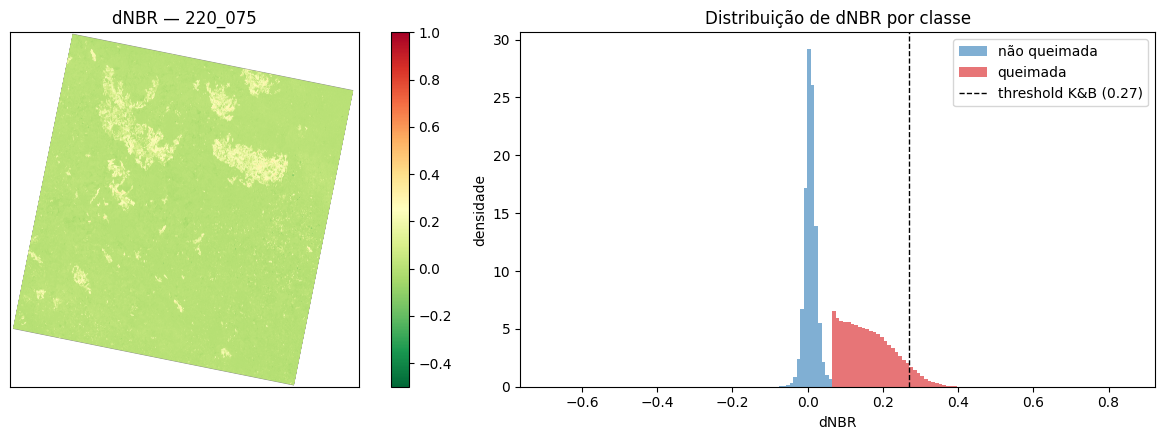

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

# Mapa do dNBR
im = axes[0].imshow(train_dnbr, cmap="RdYlGn_r", vmin=-0.5, vmax=1.0)
axes[0].set_title(f"dNBR — {TRAIN_SCENE.name}")
axes[0].set_xticks([]); axes[0].set_yticks([])
plt.colorbar(im, ax=axes[0], fraction=0.046)

# Distribuição por classe
valid = (train_mask >= 0) & np.isfinite(train_dnbr)
dnbr_v = train_dnbr[valid]
y_v = train_mask[valid]
for cls, color, label in [(0, "#2c7bb6", "não queimada"), (1, "#d7191c", "queimada")]:
    axes[1].hist(dnbr_v[y_v == cls], bins=80, alpha=0.6, color=color, label=label, density=True)
axes[1].axvline(0.27, ls="--", color="black", lw=1, label="threshold K&B (0.27)")
axes[1].set_xlabel("dNBR")
axes[1].set_ylabel("densidade")
axes[1].set_title("Distribuição de dNBR por classe")
axes[1].legend()
plt.tight_layout(); plt.show()

## 6. Preparação dos dados — split + sub-amostragem

1. **Filtrar pixels inválidos** (NaN em dNBR ou máscara = -1).
2. **Train/test split estratificado 70/30** *antes* de qualquer normalização.
   O `StandardScaler` vai dentro do `Pipeline` para evitar leakage.
3. **Sub-amostrar o conjunto de treino** mantendo a estratificação. Alvo: 20k
   amostras. SVM-RBF não escala para milhões de pixels.
4. O conjunto de teste interno fica **intocado** — mede o desempenho na
   mesma cena de treino, em pixels não usados no ajuste.

In [7]:
X_valid, y_valid, valid_pixels_train = features_and_targets(train_dnbr, train_mask)
logger.info("Pixels válidos no treino: %d (%.2f%% da cena)",
            X_valid.shape[0], 100 * X_valid.shape[0] / train_mask.size)

# Holdout estratificado 70/30
X_train_full, X_test_in, y_train_full, y_test_in = train_test_split(
    X_valid, y_valid,
    test_size=0.30,
    stratify=y_valid,
    random_state=SEED,
)

# Sub-amostragem estratificada do treino
N_TRAIN = 20_000
if X_train_full.shape[0] > N_TRAIN:
    X_train, _, y_train, _ = train_test_split(
        X_train_full, y_train_full,
        train_size=N_TRAIN,
        stratify=y_train_full,
        random_state=SEED,
    )
else:
    X_train, y_train = X_train_full, y_train_full

logger.info("Treino       : %d amostras (queimada=%.2f%%)", len(y_train), 100 * y_train.mean())
logger.info("Holdout (in) : %d amostras (queimada=%.2f%%)", len(y_test_in), 100 * y_test_in.mean())

17:03:24 [INFO] Pixels válidos no treino: 40473413 (69.42% da cena)
17:03:47 [INFO] Treino       : 20000 amostras (queimada=7.90%)
17:03:47 [INFO] Holdout (in) : 12142024 amostras (queimada=7.90%)


## 7. Baseline obrigatório — threshold fixo no dNBR (Key & Benson, 2006)

Antes de qualquer SVM, o número que o modelo precisa **bater**:
classificar como queimada quando `dNBR > 0.27` (severidade *low-moderate*
ou superior, segundo Key & Benson 2006).

In [8]:
THRESHOLD_KEY_BENSON = 0.27


def evaluate(y_true: np.ndarray, y_pred: np.ndarray, *, header: str) -> dict[str, float]:
    """Imprime e retorna as métricas padrão do projeto."""
    metrics = {
        "Accuracy":  accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall":    recall_score(y_true, y_pred, zero_division=0),
        "F1":        f1_score(y_true, y_pred, zero_division=0),
        "Kappa":     cohen_kappa_score(y_true, y_pred),
    }
    print(f"=== {header} ===")
    for k, v in metrics.items():
        print(f"{k:<10}: {v:.4f}")
    return metrics


y_pred_baseline_in = (X_test_in[:, 0] > THRESHOLD_KEY_BENSON).astype(np.int8)
metrics_baseline_in = evaluate(
    y_test_in, y_pred_baseline_in,
    header=f"Baseline (dNBR > {THRESHOLD_KEY_BENSON}) — holdout interno {TRAIN_SCENE.name}",
)

=== Baseline (dNBR > 0.27) — holdout interno 220_075 ===
Accuracy  : 0.9269
Precision : 1.0000
Recall    : 0.0754
F1        : 0.1403
Kappa     : 0.1307


## 8. TREINAMENTO — RBF-SVM com `Pipeline` + `GridSearchCV`

**Por que `Pipeline`?** O `StandardScaler` precisa ser ajustado *somente* no
fold de treino dentro de cada iteração da CV. Encapsular no `Pipeline` faz o
`GridSearchCV` cuidar disso automaticamente — sem leakage.

**Espaço de busca.**
- `C` (penalidade): regula o trade-off margem × erro.
- `γ` (raio do kernel RBF): `γ` alto → overfitting; baixo → underfitting.

**Critério de seleção.** F1 da classe positiva — métrica que pondera
precision e recall, apropriada para classes desbalanceadas.

**`class_weight="balanced"`**: peso inverso à frequência da classe.
Sem isso o SVM tenderia a prever quase tudo como "não queimada".

In [9]:
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(
        kernel="rbf",
        class_weight="balanced",
        random_state=SEED,
        cache_size=500,
    )),
])

param_grid = {
    "svm__C":     [0.1, 1.0, 10.0, 100.0],
    "svm__gamma": [0.01, 0.1, 1.0, 10.0],
}

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)

grid = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring="f1",
    cv=cv,
    n_jobs=-1,
    verbose=1,
    refit=True,
)

logger.info("Iniciando GridSearchCV (3-fold, %d combinações)...",
            len(param_grid["svm__C"]) * len(param_grid["svm__gamma"]))
grid.fit(X_train, y_train)

best_model = grid.best_estimator_
logger.info("Melhores hiperparâmetros: %s", grid.best_params_)
logger.info("Melhor F1 (CV)          : %.4f", grid.best_score_)

17:03:51 [INFO] Iniciando GridSearchCV (3-fold, 16 combinações)...


Fitting 3 folds for each of 16 candidates, totalling 48 fits


17:03:55 [INFO] Melhores hiperparâmetros: {'svm__C': 100.0, 'svm__gamma': 10.0}
17:03:55 [INFO] Melhor F1 (CV)          : 0.9978


## 9. Avaliação no holdout interno (mesma cena de treino)

Mede o desempenho em pixels da própria cena de treino que **não** entraram
no ajuste. Mais útil como sanity check do que como medida de generalização —
pixels da mesma cena tendem a ser fortemente correlacionados espacialmente.

Reportamos lado a lado **baseline × SVM**. Se o SVM não melhora aqui,
não há por que esperar que melhore na cena de teste.

In [10]:
def predict_in_chunks(model, X: np.ndarray, *, chunk: int = 500_000,
                      label: str = "predict") -> tuple[np.ndarray, np.ndarray]:
    """Predict + decision_function em chunks. Retorna (preds, scores)."""
    n = X.shape[0]
    preds = np.empty(n, dtype=np.int8)
    scores = np.empty(n, dtype=np.float32)
    for start in range(0, n, chunk):
        end = min(start + chunk, n)
        sub = X[start:end]
        preds[start:end] = model.predict(sub).astype(np.int8)
        scores[start:end] = model.decision_function(sub).astype(np.float32)
        logger.info("%s: %d / %d (%.1f%%)", label, end, n, 100 * end / n)
    return preds, scores


def report_metrics(y_true, y_pred, y_score, baseline_pred, *, scene_name: str):
    """Bloco completo: métricas, classification_report, comparação com baseline."""
    print(f"=== RBF-SVM — {scene_name} ===")
    print(f"Accuracy : {accuracy_score(y_true, y_pred):.4f}")
    print(f"Precision: {precision_score(y_true, y_pred, zero_division=0):.4f}")
    print(f"Recall   : {recall_score(y_true, y_pred, zero_division=0):.4f}")
    print(f"F1       : {f1_score(y_true, y_pred, zero_division=0):.4f}")
    print(f"Kappa    : {cohen_kappa_score(y_true, y_pred):.4f}")
    print(f"ROC-AUC  : {roc_auc_score(y_true, y_score):.4f}")
    print()
    print(classification_report(y_true, y_pred,
                                target_names=["não queimada", "queimada"],
                                digits=4, zero_division=0))
    print()
    print(f"{'Métrica':<10} {'Baseline (dNBR>0.27)':>22}   {'RBF-SVM':>10}   Δ")
    print("-" * 60)
    for name, fn in [("Accuracy", accuracy_score), ("Precision", precision_score),
                     ("Recall", recall_score), ("F1", f1_score), ("Kappa", cohen_kappa_score)]:
        kw = {"zero_division": 0} if fn in (precision_score, recall_score, f1_score) else {}
        b = fn(y_true, baseline_pred, **kw)
        s = fn(y_true, y_pred, **kw)
        sign = "+" if s - b >= 0 else ""
        print(f"{name:<10} {b:>22.4f}   {s:>10.4f}   ({sign}{s - b:.4f})")


def plot_cm_and_roc(y_true, y_pred, y_score, *, title_prefix: str):
    """Matriz de confusão + curva ROC lado a lado."""
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
    cm = confusion_matrix(y_true, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=["não queimada", "queimada"]).plot(
        ax=axes[0], cmap="Blues", values_format="d", colorbar=False
    )
    axes[0].set_title(f"Matriz de confusão — {title_prefix}")

    fpr, tpr, _ = roc_curve(y_true, y_score)
    auc_val = roc_auc_score(y_true, y_score)
    axes[1].plot(fpr, tpr, lw=2, label=f"RBF-SVM (AUC = {auc_val:.3f})")
    axes[1].plot([0, 1], [0, 1], "--", color="gray", lw=1)
    axes[1].set_xlabel("False Positive Rate")
    axes[1].set_ylabel("True Positive Rate")
    axes[1].set_title(f"Curva ROC — {title_prefix}")
    axes[1].legend(loc="lower right"); axes[1].grid(alpha=0.3)
    plt.tight_layout(); plt.show()


# Avaliação no holdout interno --------------------------------------------------
y_pred_in, y_score_in = predict_in_chunks(
    best_model, X_test_in, label=f"predict holdout {TRAIN_SCENE.name}"
)
report_metrics(
    y_test_in, y_pred_in, y_score_in, y_pred_baseline_in,
    scene_name=f"holdout interno {TRAIN_SCENE.name}",
)

17:04:05 [INFO] predict holdout 220_075: 500000 / 12142024 (4.1%)
17:04:15 [INFO] predict holdout 220_075: 1000000 / 12142024 (8.2%)
17:04:25 [INFO] predict holdout 220_075: 1500000 / 12142024 (12.4%)
17:04:34 [INFO] predict holdout 220_075: 2000000 / 12142024 (16.5%)
17:04:44 [INFO] predict holdout 220_075: 2500000 / 12142024 (20.6%)
17:04:54 [INFO] predict holdout 220_075: 3000000 / 12142024 (24.7%)
17:05:04 [INFO] predict holdout 220_075: 3500000 / 12142024 (28.8%)
17:05:14 [INFO] predict holdout 220_075: 4000000 / 12142024 (32.9%)
17:05:24 [INFO] predict holdout 220_075: 4500000 / 12142024 (37.1%)
17:05:34 [INFO] predict holdout 220_075: 5000000 / 12142024 (41.2%)
17:05:44 [INFO] predict holdout 220_075: 5500000 / 12142024 (45.3%)
17:05:54 [INFO] predict holdout 220_075: 6000000 / 12142024 (49.4%)
17:06:04 [INFO] predict holdout 220_075: 6500000 / 12142024 (53.5%)
17:06:15 [INFO] predict holdout 220_075: 7000000 / 12142024 (57.7%)
17:06:25 [INFO] predict holdout 220_075: 7500000 / 

=== RBF-SVM — holdout interno 220_075 ===
Accuracy : 0.9998
Precision: 0.9979
Recall   : 1.0000
F1       : 0.9989
Kappa    : 0.9989
ROC-AUC  : 1.0000

              precision    recall  f1-score   support

não queimada     1.0000    0.9998    0.9999  11182324
    queimada     0.9979    1.0000    0.9989    959700

    accuracy                         0.9998  12142024
   macro avg     0.9989    0.9999    0.9994  12142024
weighted avg     0.9998    0.9998    0.9998  12142024


Métrica      Baseline (dNBR>0.27)      RBF-SVM   Δ
------------------------------------------------------------
Accuracy                   0.9269       0.9998   (+0.0729)
Precision                  1.0000       0.9979   (-0.0021)
Recall                     0.0754       1.0000   (+0.9246)
F1                         0.1403       0.9989   (+0.8586)
Kappa                      0.1307       0.9989   (+0.8682)


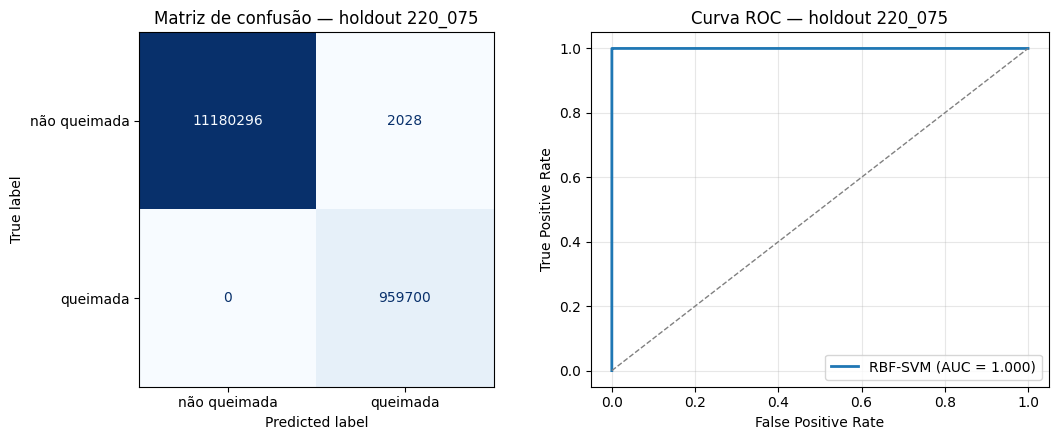

In [11]:
plot_cm_and_roc(y_test_in, y_pred_in, y_score_in,
                title_prefix=f"holdout {TRAIN_SCENE.name}")

## 10. Cena de TESTE CEGO (221_074) — nunca vista pelo modelo

Aqui está o **teste real de generalização**: aplicamos o modelo treinado em
220_075 numa cena diferente, com sensor potencialmente diferente, fenologia
diferente, e até CRS diferente (32622 vs 32623). É o cenário mais honesto.

Quedas grandes em κ ou recall em relação ao holdout interno indicam
*domain shift* — o modelo aprendeu padrões específicos da cena de treino
que não generalizam.

In [12]:
test_dnbr, test_mask = compute_dnbr(TEST_SCENE)
test_H, test_W = test_mask.shape

X_test_blind, y_test_blind, valid_pixels_test = features_and_targets(test_dnbr, test_mask)
logger.info("Cena de teste %s: %d x %d, válidos=%d (%.2f%%), queimada=%.2f%%",
            TEST_SCENE.name, test_H, test_W,
            X_test_blind.shape[0], 100 * X_test_blind.shape[0] / test_mask.size,
            100 * y_test_blind.mean())

17:08:21 [INFO] [221_074] carregando máscara
17:08:21 [INFO] [221_074] alinhando NBR_pre ao grid da máscara
17:08:22 [INFO] [221_074] alinhando NBR_pos ao grid da máscara
17:08:24 [INFO] [221_074] dNBR shape=(7821, 7721), máscara shape=(7821, 7721)
17:08:24 [INFO] Cena de teste 221_074: 7821 x 7721, válidos=40137022 (66.47%), queimada=4.89%


## 11. Avaliação na cena de teste cego

Mesmo bloco de métricas e gráficos da Seção 9, agora na cena nunca vista.
A comparação direta com a Seção 9 mostra quanto o modelo perde por mudança
de cena.

In [13]:
# Predição em chunks na cena inteira (válidos)
y_pred_blind, y_score_blind = predict_in_chunks(
    best_model, X_test_blind, label=f"predict cena {TEST_SCENE.name}"
)
y_pred_baseline_blind = (X_test_blind[:, 0] > THRESHOLD_KEY_BENSON).astype(np.int8)

report_metrics(
    y_test_blind, y_pred_blind, y_score_blind, y_pred_baseline_blind,
    scene_name=f"cena cega {TEST_SCENE.name}",
)

17:08:34 [INFO] predict cena 221_074: 500000 / 40137022 (1.2%)
17:08:43 [INFO] predict cena 221_074: 1000000 / 40137022 (2.5%)
17:08:53 [INFO] predict cena 221_074: 1500000 / 40137022 (3.7%)
17:09:03 [INFO] predict cena 221_074: 2000000 / 40137022 (5.0%)
17:09:13 [INFO] predict cena 221_074: 2500000 / 40137022 (6.2%)
17:09:23 [INFO] predict cena 221_074: 3000000 / 40137022 (7.5%)
17:09:32 [INFO] predict cena 221_074: 3500000 / 40137022 (8.7%)
17:09:42 [INFO] predict cena 221_074: 4000000 / 40137022 (10.0%)
17:09:52 [INFO] predict cena 221_074: 4500000 / 40137022 (11.2%)
17:10:01 [INFO] predict cena 221_074: 5000000 / 40137022 (12.5%)
17:10:11 [INFO] predict cena 221_074: 5500000 / 40137022 (13.7%)
17:10:21 [INFO] predict cena 221_074: 6000000 / 40137022 (14.9%)
17:10:30 [INFO] predict cena 221_074: 6500000 / 40137022 (16.2%)
17:10:40 [INFO] predict cena 221_074: 7000000 / 40137022 (17.4%)
17:10:49 [INFO] predict cena 221_074: 7500000 / 40137022 (18.7%)
17:10:59 [INFO] predict cena 221_

=== RBF-SVM — cena cega 221_074 ===
Accuracy : 0.9999
Precision: 0.9976
Recall   : 1.0000
F1       : 0.9988
Kappa    : 0.9987
ROC-AUC  : 1.0000

              precision    recall  f1-score   support

não queimada     1.0000    0.9999    0.9999  38176151
    queimada     0.9976    1.0000    0.9988   1960871

    accuracy                         0.9999  40137022
   macro avg     0.9988    0.9999    0.9994  40137022
weighted avg     0.9999    0.9999    0.9999  40137022


Métrica      Baseline (dNBR>0.27)      RBF-SVM   Δ
------------------------------------------------------------
Accuracy                   0.9545       0.9999   (+0.0454)
Precision                  1.0000       0.9976   (-0.0024)
Recall                     0.0681       1.0000   (+0.9319)
F1                         0.1276       0.9988   (+0.8712)
Kappa                      0.1221       0.9987   (+0.8766)


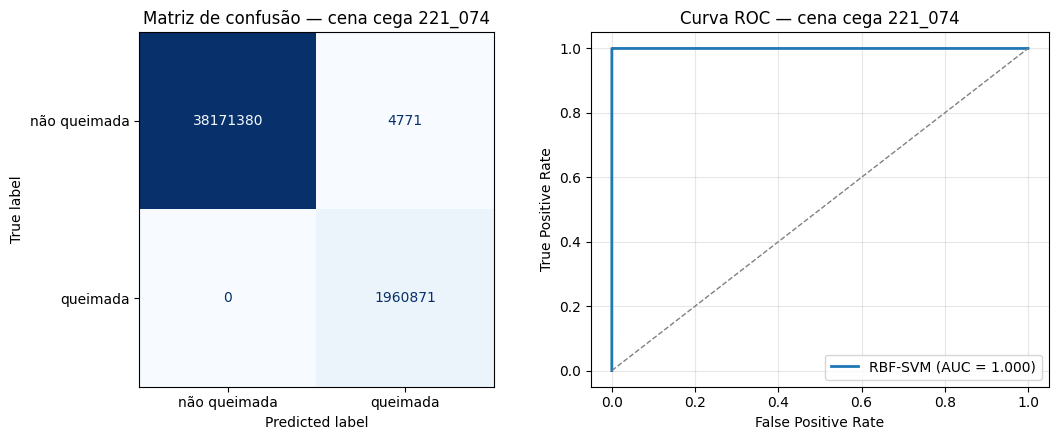

In [14]:
plot_cm_and_roc(y_test_blind, y_pred_blind, y_score_blind,
                title_prefix=f"cena cega {TEST_SCENE.name}")

### Mapas: ground truth × predição × erros (cena de teste)

- **Verde**: acerto.
- **Laranja**: falso positivo (modelo disse queimada, GT diz não).
- **Vermelho**: falso negativo (modelo perdeu queimada real).

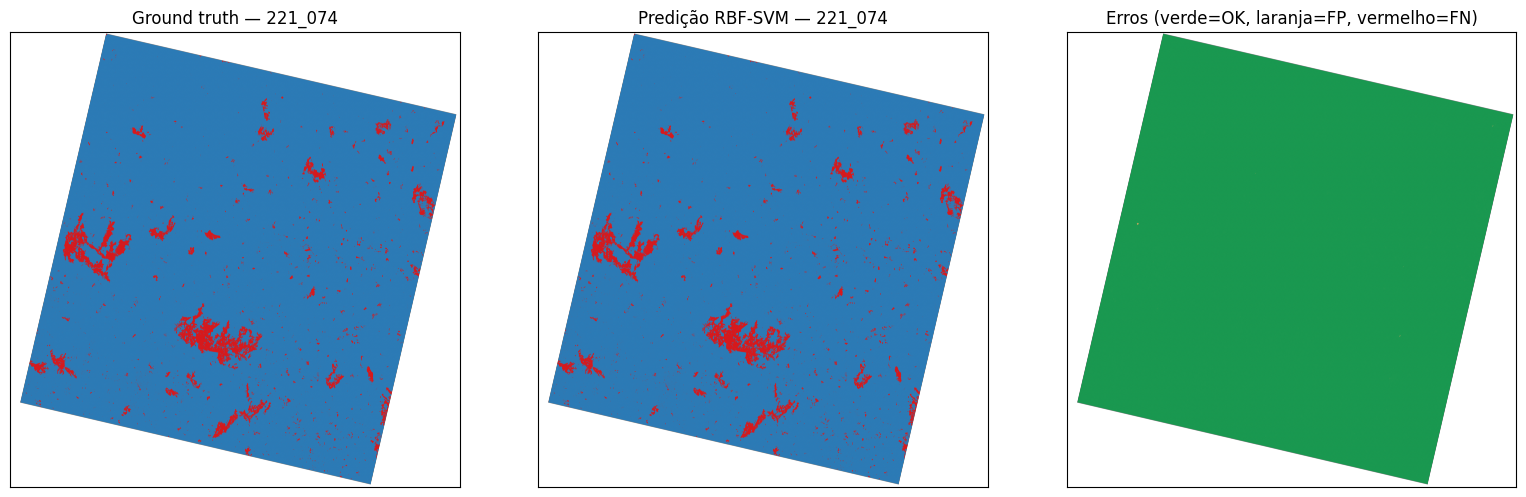

In [15]:
# Reconstrói o mapa 2D da predição cobrindo a cena toda
test_pred_full = np.full(test_H * test_W, -1, dtype=np.int8)
test_pred_full[valid_pixels_test] = y_pred_blind
test_pred_map = test_pred_full.reshape(test_H, test_W)

# Mapa de erros: 0=OK, 1=FP, 2=FN, -1=inválido
err_map = np.full((test_H, test_W), -1, dtype=np.int8)
ok = (test_mask >= 0) & (test_pred_map >= 0)
err_map[ok & (test_pred_map == test_mask)]                     = 0
err_map[ok & (test_pred_map == 1) & (test_mask == 0)]          = 1   # FP
err_map[ok & (test_pred_map == 0) & (test_mask == 1)]          = 2   # FN

cmap_cls = ListedColormap(["#2c7bb6", "#d7191c"])
cmap_err = ListedColormap(["#1a9850", "#fdae61", "#d73027"])

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
axes[0].imshow(np.ma.masked_where(test_mask < 0, test_mask), cmap=cmap_cls, vmin=0, vmax=1)
axes[0].set_title(f"Ground truth — {TEST_SCENE.name}")
axes[1].imshow(np.ma.masked_where(test_pred_map < 0, test_pred_map), cmap=cmap_cls, vmin=0, vmax=1)
axes[1].set_title(f"Predição RBF-SVM — {TEST_SCENE.name}")
axes[2].imshow(np.ma.masked_where(err_map < 0, err_map), cmap=cmap_err, vmin=0, vmax=2)
axes[2].set_title("Erros (verde=OK, laranja=FP, vermelho=FN)")
for ax in axes:
    ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.show()

## 12. SAÍDA — máscaras binárias 0/1 em GeoTIFF

Aplica o modelo em **toda** a cena (não só no holdout) e escreve dois
arquivos georreferenciados em `OUTPUT_DIR`:

- `mascara_pred_220_075.tif` — predição na cena de treino, na grade da
  máscara original. Útil para ver onde o modelo erra dentro da cena onde
  foi ajustado.
- `mascara_pred_221_074.tif` — predição na cena cega.

Codificação dos arquivos:

| Valor | Significado |
|---|---|
| `0` | não queimada |
| `1` | queimada |
| `-1` (nodata) | pixel inválido (nuvem, fora de cobertura, NaN no dNBR) |

In [16]:
def predict_full_scene(scene: Scene, dnbr: np.ndarray, mask: np.ndarray) -> np.ndarray:
    """Aplica `best_model` em toda a cena, em chunks. Retorna mapa 2D int8."""
    X, _, valid = features_and_targets(dnbr, mask)
    H, W = mask.shape
    preds, _ = predict_in_chunks(best_model, X, label=f"predict full {scene.name}")
    full = np.full(H * W, -1, dtype=np.int8)
    full[valid] = preds
    return full.reshape(H, W)


def write_geotiff_mask(pred_map: np.ndarray, ref_path: Path, out_path: Path) -> None:
    """Escreve um GeoTIFF int8 (0/1, nodata=-1) preservando CRS/transform da referência."""
    with rasterio.open(ref_path) as ref:
        profile = ref.profile.copy()
    profile.update(dtype="int8", count=1, nodata=-1, compress="lzw")
    out_path.parent.mkdir(parents=True, exist_ok=True)
    with rasterio.open(out_path, "w", **profile) as dst:
        dst.write(pred_map.astype(np.int8), 1)
    logger.info("GeoTIFF salvo em %s", out_path)


# Cena de treino: predição completa + escrita
train_pred_map = predict_full_scene(TRAIN_SCENE, train_dnbr, train_mask)
write_geotiff_mask(
    train_pred_map,
    ref_path=TRAIN_SCENE.mask,
    out_path=OUTPUT_DIR / f"mascara_pred_{TRAIN_SCENE.name}.tif",
)

# Cena cega: já temos test_pred_map, só escrever
write_geotiff_mask(
    test_pred_map,
    ref_path=TEST_SCENE.mask,
    out_path=OUTPUT_DIR / f"mascara_pred_{TEST_SCENE.name}.tif",
)

# Confirma que os arquivos existem
for p in sorted(OUTPUT_DIR.glob("*.tif")):
    print(p, p.stat().st_size, "bytes")

17:23:03 [INFO] predict full 220_075: 500000 / 40473413 (1.2%)
17:23:13 [INFO] predict full 220_075: 1000000 / 40473413 (2.5%)
17:23:23 [INFO] predict full 220_075: 1500000 / 40473413 (3.7%)
17:23:32 [INFO] predict full 220_075: 2000000 / 40473413 (4.9%)
17:23:42 [INFO] predict full 220_075: 2500000 / 40473413 (6.2%)
17:23:51 [INFO] predict full 220_075: 3000000 / 40473413 (7.4%)
17:24:00 [INFO] predict full 220_075: 3500000 / 40473413 (8.6%)
17:24:10 [INFO] predict full 220_075: 4000000 / 40473413 (9.9%)
17:24:20 [INFO] predict full 220_075: 4500000 / 40473413 (11.1%)
17:24:29 [INFO] predict full 220_075: 5000000 / 40473413 (12.4%)
17:24:38 [INFO] predict full 220_075: 5500000 / 40473413 (13.6%)
17:24:48 [INFO] predict full 220_075: 6000000 / 40473413 (14.8%)
17:24:58 [INFO] predict full 220_075: 6500000 / 40473413 (16.1%)
17:25:07 [INFO] predict full 220_075: 7000000 / 40473413 (17.3%)
17:25:17 [INFO] predict full 220_075: 7500000 / 40473413 (18.5%)
17:25:27 [INFO] predict full 220_0

/home/queimadas/Desktop/dados_trabalho_final/saida_modelo/mascara_pred_220_075.tif 2052853 bytes
/home/queimadas/Desktop/dados_trabalho_final/saida_modelo/mascara_pred_221_074.tif 1933850 bytes


## 13. Resumo e considerações finais

**O que o pipeline garante.**
- Sem data leakage: `StandardScaler` dentro do `Pipeline`, ajustado por fold
  no `GridSearchCV`. Nenhuma estatística do teste vaza para o treino.
- Estratificação preservada em todos os splits — proporção queimada/não queimada
  estável entre treino, holdout e CV.
- Reprodutibilidade: `random_state=42` em todos os pontos estocásticos
  (split, sub-amostragem, CV).
- Baseline reportado lado a lado — qualquer ganho do SVM é mensurável.
- Generalização avaliada em cena **cega**, não só no holdout interno.

**Como ler os números.**
- Se `κ_blind` ≈ `κ_holdout`: o modelo generaliza bem entre cenas. Excelente.
- Se `κ_blind` ≪ `κ_holdout`: *domain shift*. O modelo decorou padrões
  específicos da cena de treino. Mitigações:
  - Treinar com **múltiplas cenas** (juntar `220_075` + outras pré-aprovadas).
  - Adicionar features mais robustas (ex.: `NBR_pos` cru, `dNDVI`, *biome* one-hot).
  - Quantile-normalizar o dNBR por cena antes de treinar.
- Se o **baseline 0,27** está perto do SVM, o problema é essencialmente 1D
  resolvível por threshold. Não há ganho real em usar SVM, considere
  reportar o threshold ótimo aprendido (Otsu sobre dNBR, p.ex.).

**Próximos passos naturais.**
- Bootstrap (1000 réplicas) para intervalos de confiança das métricas.
- Validação espacial em blocos (bloquear o split em janelas geográficas)
  para penalizar autocorrelação espacial.
- Severidade categorizada (Key & Benson: unburned / low / moderate-low /
  moderate-high / high) com classificação multiclasse.
- Substituir SVM por Random Forest / XGBoost se quiser usar mais features
  (eles escalam linearmente em pixels).